# Frequency and Keyness

## Housekeeping (no interaction required)

In [30]:
%pip install simplemma
%pip install nltk

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import random
import time
from pathlib import Path

import pandas as pd
import nltk
import simplemma
from tqdm.notebook import tqdm

tqdm.pandas()
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /home/bode-
[nltk_data]     wsl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [32]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

In [33]:
confirm()

True

## Setup (Interaction required)

## Load the data


### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [46]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armenpflege"
LOAD_OWN_DATA = True
### ⬆️⬆️⬆️

In [47]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

In [48]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

In [49]:
if LOAD_OWN_DATA:
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.csv"
    # raw_df = pd.read_csv(RAWDATA_PATH, index_col="id")

    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet"
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load from Github

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [38]:
if not LOAD_OWN_DATA:
    RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.csv"
    raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    # raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

⚙️ Only for development, delete for summer school!

In [39]:
# raw_df = raw_df.reset_index()[["id", "meta.date", "meta.mediaTitle", "text.itemTypeLabel", "text.content", "text.contentLength"]]
# raw_df = raw_df.set_index("id")

### Parse data

In [50]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## Preprocess Corpus

In [ ]:
confirm("Do you want to preprocess the corpus?")

def sentencize(s: str) -> list[str]:
    sentences = nltk.tokenize.sent_tokenize(s, language="german")
    return sentences

def tokenize(s: str) -> list[str]:
    tokens = nltk.tokenize.word_tokenize(s, language="german")
    return tokens

def lemmatize(s: list[str]) -> list[str]:
    lemmatized = [simplemma.lemmatize(word, lang="de") for word in s]
    return lemmatized

# import re
# replacement_pairs = [
#     (re.compile(r"^Th"), "T"),
#     (re.compile(r"^th"), "t"),
#     (re.compile(r"th$"), "t"),
#     (re.compile(r"ß"), "s"),
# ]
# def normalize(s: list[str]) -> list[str]:
#     tokens = []
#     for tok in s:
#         for regex, replacement in replacement_pairs:
#             tok = regex.sub(replacement, tok)
#         tokens.append(tok)
#     return tokens

tqdm.pandas(desc="Applying sentencization")
raw_df["_sentences"] = raw_df["content"].progress_apply(sentencize)

tqdm.pandas(desc="Applying tokenization")
raw_df["tokens"] = raw_df["_sentences"].progress_apply(lambda sentences: [tokenize(sentence) for sentence in sentences])

#tqdm.pandas(desc="Applying lemmatization")
#raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(normalize(token_list)) for token_list in tokens])

tqdm.pandas(desc="Applying lemmatization")
raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(token_list) for token_list in tokens])

if LOAD_OWN_DATA:
    raw_df[["_sentences"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet")
    raw_df[["lemmas"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    raw_df[["tokens"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")


Applying sentencization:   0%|          | 0/3175 [00:00<?, ?it/s]

Applying tokenization:   0%|          | 0/3175 [00:00<?, ?it/s]

Applying lemmatization:   0%|          | 0/3175 [00:00<?, ?it/s]

Load the data

In [53]:
confirm = input("Do you want to load precomputed tokens and lemmas? (y/n) ")
assert confirm.lower() in ("y"), "❌ Cancelled."
print("✅ Loading data from source...")

if LOAD_OWN_DATA:
    lemma_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    wordform_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")
else:
    LEMMA_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.lemmas.parquet"
    lemma_df = pd.read_parquet(LEMMA_URL)

    TOKENS_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.tokens.parquet"
    wordform_df = pd.read_parquet(TOKENS_URL)

✅ Loading data from source...


In [54]:
if "lemmas" not in raw_df.columns:
    raw_df = raw_df.join(lemma_df)

if "tokens" not in raw_df.columns:
    raw_df = raw_df.join(wordform_df)

## Frequency Analyses

In [55]:
from collections import Counter

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

lemma_c = count_tokens(raw_df, "lemmas")

lemma_c.most_common(10)

Counting Tokens:   0%|          | 0/2633 [00:00<?, ?it/s]

[('der', 687727),
 (',', 441963),
 ('.', 350565),
 ('und', 146670),
 ('ein', 118535),
 ('sein', 118053),
 ('in', 106714),
 ('»', 100683),
 ('«', 95437),
 ('werden', 83025)]

### Compare Frequency across Time

In [56]:
from typing import Dict
import matplotlib.pyplot as plt

class FrequencyAnalysisDiachronic:
    def __init__(self, df: pd.DataFrame, column: str, n_years: int):
        self.df = df.copy()
        self.column = column

        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()

        self.interval_counters = self.get_frequency_by_interval(n_years)
        self.intervals = list(self.interval_counters.keys())
        self.interval_total = {
            interval: sum(counter.values())
            for interval, counter
            in self.interval_counters.items()
        }

    def get_frequency_by_interval(self, n_years: int) -> Dict[str, Counter]:
        if n_years <= 0:
            raise ValueError("n_years must be a positive integer.")

        # Snap start to the nearest lower multiple of n_years
        start = (self.min_year // n_years) * n_years
        stop = self.max_year + n_years

        bins = list(range(start, stop + 1, n_years))
        labels = [f"{y}-{y + n_years - 1}" for y in bins[:-1]]

        # Assign each document to a year bucket
        # With n_years = 25:
        #   1833 -> 1825 -> "1825-1849"
        #   1900 -> 1900 -> "1900-1924"
        #   1898 -> 1875 -> "1875-1899"
        self.df["year_interval"] = pd.cut(self.df["year"], bins=bins, labels=labels, include_lowest=True)

        # Calculate counts for each interval
        interval_counters = {}
        # Filter out NaN intervals if any document year falls outside the defined bins
        for interval in tqdm(labels, desc="Iterating intervals"):
            group_df = self.df[self.df["year_interval"] == interval]
            interval_counters[interval] = count_tokens(group_df, column=self.column)
        return interval_counters

    def get_abs_frequencies_for_word(self, word: str) -> Dict[str, int]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word]
        return frequencies

    def get_rel_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = {}
        for interval in self.intervals:
            try:
                frequencies[interval] = self.interval_counters[interval][word] / self.interval_total[interval]
            except ZeroDivisionError:
                frequencies[interval] = 0.0
        return frequencies

    def get_norm_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = self.get_rel_frequencies_for_word(word)
        frequencies = {interval: freq * 1000000 for interval, freq in frequencies.items()}
        return frequencies

    def plot_interval_totals(self):
        fig, ax = plt.subplots(figsize=(12, 3))

        ax.bar(self.intervals, [self.interval_total[interval] for interval in self.intervals])

        ax.tick_params(axis='x', rotation=45)
        # ax.legend(title="Words")
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()

    def plot_relative_frequencies(self, words: list[str]):
        fig, ax = plt.subplots(figsize=(12, 6))

        for word in words:
            rel_freqs = self.get_rel_frequencies_for_word(word)
            series = pd.Series(rel_freqs)
            ax.plot(series.index.astype(str), series.values, label=word, marker='o', markersize=4)

        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()


In [57]:
fa_diachron = FrequencyAnalysisDiachronic(raw_df, "lemmas", 10)

Iterating intervals:   0%|          | 0/20 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/1 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/8 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/3 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/35 [00:00<?, ?it/s]

...

Counting Tokens:   0%|          | 0/144 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/58 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/4 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/12 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/3 [00:00<?, ?it/s]

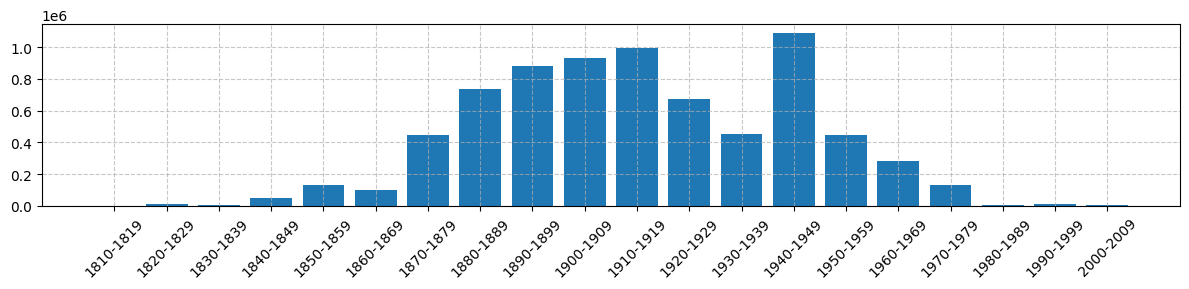

In [58]:
fa_diachron.plot_interval_totals()

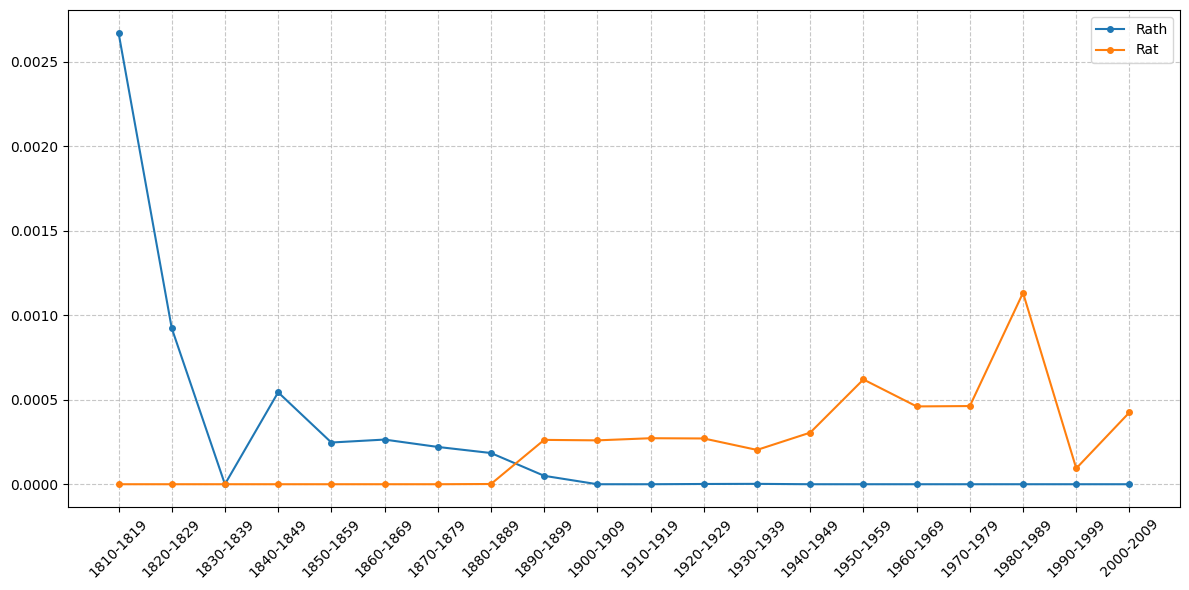

In [62]:
fa_diachron.plot_relative_frequencies(["Rath", "Rat"])

## Compare Frequencies

In [ ]:
import math

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

class KeynessComparer:
    def __init__(self, df1: pd.DataFrame, df2: pd.DataFrame, column: str = "lemmas", freq_filter=5):
        self.df1 = df1
        self.df2 = df2
        self.column = column
        self.freq_filter = freq_filter

        self.counter1 = count_tokens(self.df1, self.column)
        self.counter2 = count_tokens(self.df2, self.column)

        self.total_tokens1 = sum(self.counter1.values())
        self.total_tokens2 = sum(self.counter2.values())

        # Apply the frequency filter
        self.counter1 = Counter({token: count for token, count in self.counter1.items() if count >= self.freq_filter})
        self.counter2 = Counter({token: count for token, count in self.counter2.items() if count >= self.freq_filter})

        self.df = self.build_contingency_df()

    def build_contingency_df(self) -> pd.DataFrame:
        all_tokens = set(self.counter1.keys()) | set(self.counter2.keys())
        data = []
        for token in tqdm(all_tokens, desc="Build Contingency Table"):
            observed_tok_1 = self.counter1[token]
            observed_tok_2 = self.counter2[token]
            observed_notok_1 = self.total_tokens1 - observed_tok_1
            observed_notok_2 = self.total_tokens2 - observed_tok_2

            # Expected frequencies under the null hypothesis of no association between token and corpus
            expected_tok_1 = (observed_tok_1 + observed_tok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_tok_2 = (observed_tok_1 + observed_tok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_1 = (observed_notok_1 + observed_notok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_2 = (observed_notok_1 + observed_notok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)

            data.append({
                "token": token,
                "observed_tok_1": observed_tok_1,
                "observed_tok_2": observed_tok_2,
                "observed_notok_1": observed_notok_1,
                "observed_notok_2": observed_notok_2,
                "expected_tok_1": expected_tok_1,
                "expected_tok_2": expected_tok_2,
                "expected_notok_1": expected_notok_1,
                "expected_notok_2": expected_notok_2,
                "prevalent_1": True if observed_tok_1 > expected_tok_1 else False,
            })
        contingency_df = pd.DataFrame(data)
        return contingency_df

    def log_likelihood_ratio(self, contingency_row: pd.Series) -> float:
        G = 0.0
        for token_presence in ["tok", "notok"]:
            for corpus in ["1", "2"]:
                observed = contingency_row[f"observed_{token_presence}_{corpus}"]
                expected = contingency_row[f"expected_{token_presence}_{corpus}"]

                if observed > 0 and expected > 0:
                    G += observed * math.log(observed / expected)
        return 2 * G


    def log_ratio(self, contingency_row: pd.Series) -> float:
        observed_tok_1 = contingency_row["observed_tok_1"]
        observed_tok_2 = contingency_row["observed_tok_2"]
        logprob1 = math.log((observed_tok_1 + 1/2) / (self.total_tokens1 + 1/2))  # Add-one smoothing
        logprob2 = math.log((observed_tok_2 + 1/2) / (self.total_tokens2 + 1/2))  # Add-one smoothing

        return logprob1 - logprob2

    def build_keyness_df(self) -> pd.DataFrame:
        tqdm.pandas(desc="Calculating log likelihood ratio")
        self.df["llr"] = self.df.progress_apply(self.log_likelihood_ratio, axis=1)
        tqdm.pandas(desc="Calculating log ratio")
        self.df["log_ratio"] = self.df.progress_apply(self.log_ratio, axis=1)
        return self.df

In [ ]:
df_pre1920 = raw_df[raw_df["year"] < 1920]
df_post1920 = raw_df[raw_df["year"] >= 1920]

kf = KeynessComparer(df_pre1920, df_post1920)

In [ ]:
df_pre1920 = raw_df[raw_df["year"] < 1920]

df_tat = df_pre1920[df_pre1920["meta.mediaTitle"] == "Die Tat"]
df_nzz = df_pre1920[df_pre1920["meta.mediaTitle"] == "Neue Zürcher Zeitung"]
kf = KeynessComparer(df_tat, df_nzz, freq_filter=3)

In [ ]:
kf.__class__ = KeynessComparer

In [ ]:
kf.build_keyness_df()

In [ ]:
kf.df.sort_values("log_ratio", ascending=False).head(10)